# Crop-Yield Integration Pipeline (Member 4 Part) — v2
### Weather-Uncertainty-Aware Indian Crop Yield Prediction

Builds the common District x Crop x Season x Year feature layer, merges the three
weather-risk verticals (ENSO, Western Disturbance, Cloudburst), joins with crop-yield
data, and runs the ablation framework to test whether each vertical adds real
predictive value.

## Data status

| Component | Status | Source |
|---|---|---|
| **ENSO features** | REAL | `enso_vertical_output.csv` (Sahithi) - monthly Nino 3.4 forecasts |
| **Western Disturbance features** | REAL | `WD_monthly_counts_India.csv` (Dorothy/Swagato) - monthly WD event counts, India-wide, 1950-2019 |
| **Cloudburst features** | REAL (partial coverage) | `cloudburst_features.csv` -- district-level extreme-rainfall risk from NASA POWER daily data + IMD thresholds, 1989-2020, 5 districts only (Guntur, Kota, Ludhiana, Nashik/Nasik, Patna) |
| **Crop yield data** | REAL | ICRISAT District Level Database (official, public) - district-wise Wheat/Rice yield, 1966-2017 |

Notes and assumptions:
- WD counts are India-wide (no district breakdown available), so - exactly like ENSO -
  the same national value is applied to every district in a given crop year. This
  matches how the project spec treats ENSO (large-scale, applies across districts).
- ICRISAT's `Year` column is treated as the crop year (Kharif starts within that
  calendar year; Rabi is sown late in that year and harvested early the next). This
  is a standard convention but worth double-checking against ICRISAT's data
  documentation if exact alignment matters for your final report.
- ICRISAT uses `-1` as a missing/not-applicable code; these rows are dropped.
- Cloudburst is now real but only covers 5 districts (the vertical hasn't been run for the
  full district list yet). Rows for districts outside this set get NaN cloudburst
  features, not zeros -- the ablation loop below drops NaNs per-variant so
  Baseline/ENSO/WD models still use the full district set, and only
  Cloudburst-involving variants are restricted to the 5 covered districts.
- Cloudburst district names are harmonized to ICRISAT spelling (`Nashik` -> `Nasik`).


In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RNG = np.random.default_rng(42)
pd.set_option("display.max_columns", 50)


## 1. Load real ENSO features (Sahithi's vertical)

Monthly ENSO forecasts aggregated to crop-year level (June of year Y to May of year Y+1).


In [2]:
enso_raw = pd.read_csv("data/enso_vertical_output.csv", parse_dates=["Date"])
enso_raw = enso_raw.rename(columns={"predicted_anomaly": "enso_predicted_anomaly"})

enso_raw["crop_year"] = np.where(enso_raw["Date"].dt.month >= 6,
                                  enso_raw["Date"].dt.year,
                                  enso_raw["Date"].dt.year - 1)

enso_yearly = (
    enso_raw.groupby("crop_year")
    .agg(
        enso_predicted_anomaly=("enso_predicted_anomaly", "mean"),
        enso_el_nino_probability=("enso_el_nino_probability", "mean"),
        enso_neutral_probability=("enso_neutral_probability", "mean"),
        enso_la_nina_probability=("enso_la_nina_probability", "mean"),
        enso_forecast_confidence=("enso_forecast_confidence", "mean"),
    )
    .reset_index()
    .rename(columns={"crop_year": "year"})
)

print(f"ENSO yearly features: {enso_yearly.shape[0]} crop-years "
      f"({enso_yearly['year'].min()}-{enso_yearly['year'].max()})")
enso_yearly.head()


ENSO yearly features: 75 crop-years (1950-2024)


,year,enso_predicted_anomaly,enso_el_nino_probability,enso_neutral_probability,enso_la_nina_probability,enso_forecast_confidence
0,1950,0.077260,0.138332,0.789998,0.071670,0.789998
1,1951,0.164810,0.252812,0.665171,0.082017,0.735289
2,1952,-0.200048,0.125000,0.539778,0.335221,0.714656
3,1953,-0.116758,0.144374,0.615020,0.240606,0.784554
4,1954,-1.163695,0.000906,0.078486,0.920609,0.926952


## 2. Load real Western Disturbance features (Dorothy/Swagato's vertical)

`WD_monthly_counts_India.csv` has real monthly WD event counts for India, 1950-2019.
Aggregated to crop-year level the same way as ENSO. Since this is India-wide (no
district column), it applies as one national value per crop year, same as ENSO.


In [3]:
wd_raw = pd.read_csv("data/WD_monthly_counts_India.csv")

wd_raw["crop_year"] = np.where(wd_raw["Month"] >= 6, wd_raw["Year"], wd_raw["Year"] - 1)

wd_yearly = (
    wd_raw.groupby("crop_year")
    .agg(
        wd_expected_count=("WD_Count", "sum"),
        wd_mean_monthly_count=("WD_Count", "mean"),
    )
    .reset_index()
    .rename(columns={"crop_year": "year"})
)

print(f"WD yearly features: {wd_yearly.shape[0]} crop-years "
      f"({wd_yearly['year'].min()}-{wd_yearly['year'].max()})")
wd_yearly.head()


WD yearly features: 70 crop-years (1949-2018)


,year,wd_expected_count,wd_mean_monthly_count
0,1949,51,10.200000
1,1950,98,8.166667
2,1951,83,7.545455
3,1952,95,7.916667
4,1953,80,6.666667


## 3. Load real Cloudburst features (Workflow 3 vertical)

`cloudburst_features.csv` -- district-level extreme-rainfall risk, built from real
NASA POWER daily precipitation/humidity/temperature data and IMD's official 24-hour
rainfall intensity thresholds (>=204.5mm = "Extremely Heavy", used as the cloudburst
proxy since sub-daily radar data for a literal cloudburst definition isn't available).

Coverage is currently 5 districts (Guntur, Kota, Ludhiana, Nashik, Patna), 1989-2020 --
the vertical hasn't been run for the full ICRISAT district list yet. District names
are harmonized to ICRISAT's spelling (`Nashik` -> `Nasik`); everything else is used
as-is. Districts/years outside this coverage get `NaN`, not a fabricated value.

In [4]:
CLOUDBURST_DISTRICT_ALIASES = {
    "Nashik": "Nasik",  # cloudburst_features.csv uses NASA POWER geocoding spelling;
                         # ICRISAT panel uses "Nasik"
}

def load_real_cloudburst_features(path="data/cloudburst_features.csv"):
    '''Real cloudburst vertical output (NASA POWER + IMD thresholds). Replaces the
    old generate_placeholder_cloudburst_features() now that the vertical exists.'''
    df = pd.read_csv(path)
    df["district"] = df["district"].replace(CLOUDBURST_DISTRICT_ALIASES)
    return df[["district", "year", "cloudburst_probability",
               "extreme_rainfall_days", "cloudburst_severity"]]

## 4. Load real crop yield data (ICRISAT District Level Database)

Official, public dataset. Wide format (one row per District-Year, columns per crop).
We reshape Wheat (Rabi) and Rice (Kharif) yield columns into the long
District x Crop x Season x Year format the project spec requires. ICRISAT uses `-1`
to mark missing/not-applicable values, which are dropped, along with true `0`
placeholders that indicate the crop wasn't grown that year in that district.


In [5]:
icrisat = pd.read_csv("data/ICRISAT-District_Level_Data.csv")
icrisat.columns = [c.strip() for c in icrisat.columns]

def melt_crop(df, crop_col, crop_name, season):
    sub = df[["State Name", "Dist Name", "Year", crop_col]].copy()
    sub = sub.rename(columns={"State Name": "state", "Dist Name": "district",
                               "Year": "year", crop_col: "yield"})
    sub["crop"] = crop_name
    sub["season"] = season
    sub = sub[sub["yield"] > 0]  # drop -1 (missing) and 0 (not grown) codes
    return sub

wheat = melt_crop(icrisat, "WHEAT YIELD (Kg per ha)", "Wheat", "Rabi")
rice = melt_crop(icrisat, "RICE YIELD (Kg per ha)", "Rice", "Kharif")

yield_panel = pd.concat([wheat, rice], ignore_index=True)
yield_panel["yield"] = yield_panel["yield"] / 1000  # Kg/ha -> tonnes/ha, matches typical reporting

print(f"Yield panel: {yield_panel.shape[0]} rows, "
      f"{yield_panel['district'].nunique()} districts, "
      f"{yield_panel['year'].min()}-{yield_panel['year'].max()}")
yield_panel.head()


Yield panel: 28723 rows, 311 districts, 1966-2017


,state,district,year,yield,crop,season
0,Chhattisgarh,Durg,1966,0.45455,Wheat,Rabi
1,Chhattisgarh,Durg,1967,0.52000,Wheat,Rabi
2,Chhattisgarh,Durg,1968,0.55866,Wheat,Rabi
3,Chhattisgarh,Durg,1969,0.53644,Wheat,Rabi
4,Chhattisgarh,Durg,1970,0.65611,Wheat,Rabi


## 5. Build the common District x Crop x Season x Year feature layer

ENSO and WD are year-level (apply to every district equally); Cloudburst is
district x year level and real, but only for its 5 covered districts. All are
joined onto the real yield panel; uncovered district-years get NaN cloudburst
features rather than a fabricated value.


In [6]:
districts = yield_panel["district"].unique()
years = sorted(yield_panel["year"].unique())
cloudburst_features = load_real_cloudburst_features(path="data/cloudburst_features.csv")

common = yield_panel.merge(enso_yearly, on="year", how="left")
common = common.merge(wd_yearly, on="year", how="left")
common = common.merge(cloudburst_features, on=["district", "year"], how="left")

print(f"Common feature layer: {common.shape[0]} rows, {common.shape[1]} columns")
n_with_cloudburst = common["cloudburst_probability"].notna().sum()
print(f"Rows with real cloudburst coverage: {n_with_cloudburst} "
      f"({n_with_cloudburst / len(common):.1%}) -- expected to be small, "
      f"limited to the 5 covered districts/years")
common.head()

Common feature layer: 28723 rows, 16 columns
Rows with real cloudburst coverage: 263 (0.9%) -- expected to be small, limited to the 5 covered districts/years


,state,district,year,yield,crop,season,enso_predicted_anomaly,enso_el_nino_probability,enso_neutral_probability,enso_la_nina_probability,enso_forecast_confidence,wd_expected_count,wd_mean_monthly_count,cloudburst_probability,extreme_rainfall_days,cloudburst_severity
0,Chhattisgarh,Durg,1966,0.45455,Wheat,Rabi,-0.506874,0.014916,0.471150,0.513934,0.713076,94,7.833333,NaN,NaN,NaN
1,Chhattisgarh,Durg,1967,0.52000,Wheat,Rabi,-0.695350,0.005008,0.323478,0.671514,0.738973,85,7.727273,NaN,NaN,NaN
2,Chhattisgarh,Durg,1968,0.55866,Wheat,Rabi,0.405188,0.392468,0.580678,0.026854,0.790202,66,6.000000,NaN,NaN,NaN
3,Chhattisgarh,Durg,1969,0.53644,Wheat,Rabi,0.120740,0.251347,0.618976,0.129677,0.705384,79,7.181818,NaN,NaN,NaN
4,Chhattisgarh,Durg,1970,0.65611,Wheat,Rabi,-1.234289,0.000278,0.037909,0.961814,0.961814,76,6.909091,NaN,NaN,NaN


## 6. Feature quality checks

In [7]:
missing = common.isna().sum()
missing = missing[missing > 0]
print("Missing values per column (ENSO/WD: years outside overlap range; "
      "Cloudburst: districts outside its 5-district coverage -- expected, kept as NaN "
      "rather than dropped globally, and handled per-variant in the ablation loop below):")
print(missing if len(missing) else "None")

# Drop rows where ENSO/WD data isn't available (years outside their coverage)
before = len(common)
common = common.dropna(subset=["enso_predicted_anomaly", "wd_expected_count"])
print(f"\nDropped {before - len(common)} rows outside ENSO/WD year coverage "
      f"({common['year'].min()}-{common['year'].max()} remains)")

print("\nValue ranges (sanity check):")
print(common[["yield", "enso_el_nino_probability", "wd_expected_count",
              "cloudburst_probability"]].describe().loc[["min", "max"]])


Missing values per column (ENSO/WD: years outside overlap range; Cloudburst: districts outside its 5-district coverage -- expected, kept as NaN rather than dropped globally, and handled per-variant in the ablation loop below):
cloudburst_probability    28460
extreme_rainfall_days     28460
cloudburst_severity       28460
dtype: int64

Dropped 0 rows outside ENSO/WD year coverage (1966-2017 remains)

Value ranges (sanity check):
       yield  enso_el_nino_probability  wd_expected_count  \
min  0.00912                  0.000090               66.0   
max  5.65383                  0.889688              113.0   

     cloudburst_probability  
min                0.000000  
max                0.002142  


## 7. Ablation framework - define feature sets

Baseline, then each vertical added individually, then combinations, then Full model.


In [8]:
BASELINE_FEATURES = []
ENSO_FEATURES = ["enso_predicted_anomaly", "enso_el_nino_probability", "enso_la_nina_probability"]
WD_FEATURES = ["wd_expected_count", "wd_mean_monthly_count"]
CLOUDBURST_FEATURES = ["cloudburst_probability", "extreme_rainfall_days", "cloudburst_severity"]

MODEL_VARIANTS = {
    "Baseline":            BASELINE_FEATURES,
    "Model A (ENSO)":      ENSO_FEATURES,
    "Model B (WD)":        WD_FEATURES,
    "Model C (Cloudburst)": CLOUDBURST_FEATURES,
    "Model D (ENSO+WD)":   ENSO_FEATURES + WD_FEATURES,
    "Model E (ENSO+Cloudburst)": ENSO_FEATURES + CLOUDBURST_FEATURES,
    "Model F (WD+Cloudburst)":   WD_FEATURES + CLOUDBURST_FEATURES,
    "Full model (all three)":    ENSO_FEATURES + WD_FEATURES + CLOUDBURST_FEATURES,
}

for name, feats in MODEL_VARIANTS.items():
    print(f"{name}: {feats if feats else '[district/crop one-hot only]'}")


Baseline: [district/crop one-hot only]
Model A (ENSO): ['enso_predicted_anomaly', 'enso_el_nino_probability', 'enso_la_nina_probability']
Model B (WD): ['wd_expected_count', 'wd_mean_monthly_count']
Model C (Cloudburst): ['cloudburst_probability', 'extreme_rainfall_days', 'cloudburst_severity']
Model D (ENSO+WD): ['enso_predicted_anomaly', 'enso_el_nino_probability', 'enso_la_nina_probability', 'wd_expected_count', 'wd_mean_monthly_count']
Model E (ENSO+Cloudburst): ['enso_predicted_anomaly', 'enso_el_nino_probability', 'enso_la_nina_probability', 'cloudburst_probability', 'extreme_rainfall_days', 'cloudburst_severity']
Model F (WD+Cloudburst): ['wd_expected_count', 'wd_mean_monthly_count', 'cloudburst_probability', 'extreme_rainfall_days', 'cloudburst_severity']
Full model (all three): ['enso_predicted_anomaly', 'enso_el_nino_probability', 'enso_la_nina_probability', 'wd_expected_count', 'wd_mean_monthly_count', 'cloudburst_probability', 'extreme_rainfall_days', 'cloudburst_severity']

## 8. Train + evaluate each variant

Chronological split (train on earlier years, test on later years) to avoid leakage.
Crop/season/state are one-hot encoded; district is **target-encoded** (historical
average yield, computed from the training split only) rather than one-hot encoded,
since one-hot encoding 311 districts both slowed training and diluted the model's
strongest predictor. All of this is included in every variant as minimal identifying
context, on top of which the weather features are added per the ablation table above.


In [9]:
# District is high-cardinality (311 levels), so one-hot encoding it directly is what
# was blowing up dimensionality and slowing training. District identity is also the
# single biggest driver of yield (soil, irrigation, local practice), so dropping it
# entirely (as the first pass did) starves every model -- including baseline -- of its
# main signal, which is why R2 came out negative across the board.
#
# Fix: target-encode district as its historical average yield, computed ONLY from the
# training split (to avoid leakage), then mapped onto both train and test rows. This
# keeps district's signal without a 311-column one-hot matrix.
common_enc = pd.get_dummies(common, columns=["crop", "season", "state"], drop_first=True)
id_cols = [c for c in common_enc.columns
           if c.startswith(("crop_", "season_", "state_"))]

split_year = int(common["year"].quantile(0.8))
TRAIN = common["year"] <= split_year
TEST = common["year"] > split_year
print(f"Train: years <= {split_year} ({TRAIN.sum()} rows). "
      f"Test: years > {split_year} ({TEST.sum()} rows).")

district_avg_yield = (
    common.loc[TRAIN]
    .groupby("district")["yield"]
    .mean()
)
overall_train_mean = common.loc[TRAIN, "yield"].mean()

common_enc["district_avg_yield"] = (
    common["district"].map(district_avg_yield).fillna(overall_train_mean)
)
id_cols = id_cols + ["district_avg_yield"]

# Cloudburst now has real NaNs for districts outside its 5-district coverage (id_cols
# are never NaN). sklearn's RandomForestRegressor can't handle NaN, so each variant
# drops rows missing ITS OWN features rather than a single global dropna -- this keeps
# Baseline/ENSO/WD at full district coverage and only shrinks Cloudburst-involving
# variants to the districts that vertical actually covers. Row counts are logged per
# variant since R2/RMSE aren't directly comparable across very different sample sizes.
results = []
for name, feats in MODEL_VARIANTS.items():
    X_cols = id_cols + feats
    variant_ok = common_enc[X_cols].notna().all(axis=1)
    v_train = TRAIN & variant_ok
    v_test = TEST & variant_ok

    X_train, X_test = common_enc.loc[v_train, X_cols], common_enc.loc[v_test, X_cols]
    y_train, y_test = common.loc[v_train, "yield"], common.loc[v_test, "yield"]

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"Skipping {name}: no train or test rows after dropping NaNs "
              f"(train={len(X_train)}, test={len(X_test)})")
        continue

    model = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "Model": name,
        "Train rows": len(X_train),
        "Test rows": len(X_test),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df

Train: years <= 2007 (23269 rows). Test: years > 2007 (5454 rows).


,Model,Train rows,Test rows,MAE,RMSE,R2
6,Model F (WD+Cloudburst),172,91,0.653884,0.780043,0.612223
7,Full model (all three),172,91,0.654521,0.790067,0.602193
3,Model C (Cloudburst),172,91,0.662233,0.793941,0.598282
5,Model E (ENSO+Cloudburst),172,91,0.662029,0.795186,0.597021
1,Model A (ENSO),23269,5454,0.793442,0.996588,0.070066
0,Baseline,23269,5454,0.839828,1.012510,0.040115
4,Model D (ENSO+WD),23269,5454,0.847123,1.043658,-0.019853
2,Model B (WD),23269,5454,0.894580,1.106202,-0.145750


## 9. Results comparison

Reminder: ENSO, WD, Cloudburst, and yield are now all real. Cloudburst-involving
variants (C, E, F, Full) run on a much smaller sample -- only the 5 districts that
vertical currently covers -- so compare their RMSE/R2 against Baseline/A/B/D with
that N difference in mind, not as a clean apples-to-apples comparison. `Train rows`
/ `Test rows` in the results table make the gap explicit.

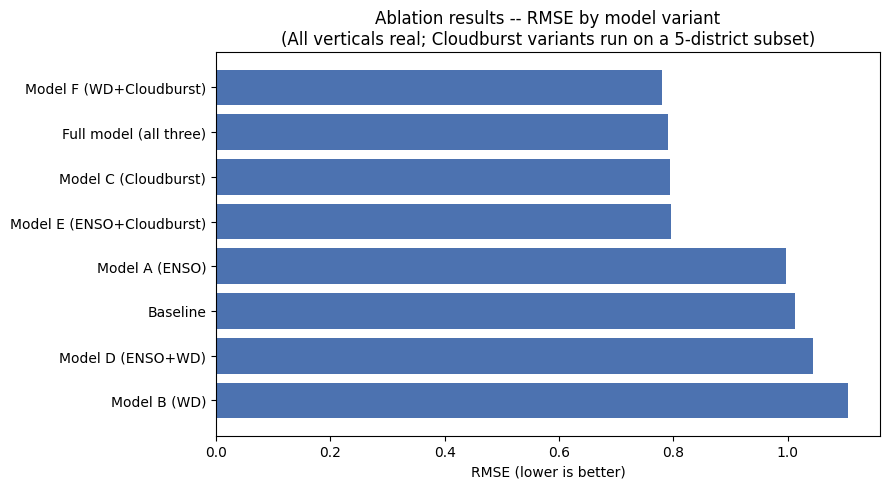

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results_df["Model"], results_df["RMSE"], color="#4C72B0")
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Ablation results -- RMSE by model variant\n(All verticals real; Cloudburst variants run on a 5-district subset)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Fair ablation — same subset for every variant

Section 8's comparison isn't apples-to-apples: Cloudburst-involving variants (C, E, F,
Full) evaluate on only 172 train / 91 test rows (the 5 districts Cloudburst covers),
while Baseline/A/B/D evaluate on the full 23,269 / 5,454 rows. Different test sets have
different inherent variance, so their R2/RMSE aren't directly comparable — a smaller,
more homogeneous subset can look "better" for reasons that have nothing to do with the
features included.

This section re-runs **all 8 variants restricted to the exact same rows** (the
intersection where Cloudburst data exists), so the only thing that changes between
variants is which features are included — the actual point of an ablation study.


In [11]:
# Restrict to rows where Cloudburst features exist, so every variant (including
# Baseline/A/B/D) is evaluated on the identical set of districts/years.
cloudburst_ok = common_enc[CLOUDBURST_FEATURES].notna().all(axis=1)

fair_results = []
for name, feats in MODEL_VARIANTS.items():
    X_cols = id_cols + feats
    v_train = TRAIN & cloudburst_ok
    v_test = TEST & cloudburst_ok

    X_train, X_test = common_enc.loc[v_train, X_cols], common_enc.loc[v_test, X_cols]
    y_train, y_test = common.loc[v_train, "yield"], common.loc[v_test, "yield"]

    if len(X_train) == 0 or len(X_test) == 0:
        print(f"Skipping {name}: no rows in the common subset (train={len(X_train)}, test={len(X_test)})")
        continue

    model = RandomForestRegressor(n_estimators=200, max_depth=14, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    fair_results.append({
        "Model": name,
        "Train rows": len(X_train),
        "Test rows": len(X_test),
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    })

fair_results_df = pd.DataFrame(fair_results).sort_values("RMSE")
print("Fair ablation -- identical train/test rows across all variants:")
fair_results_df


Fair ablation -- identical train/test rows across all variants:


,Model,Train rows,Test rows,MAE,RMSE,R2
6,Model F (WD+Cloudburst),172,91,0.653884,0.780043,0.612223
7,Full model (all three),172,91,0.654521,0.790067,0.602193
2,Model B (WD),172,91,0.651515,0.791973,0.600271
3,Model C (Cloudburst),172,91,0.662233,0.793941,0.598282
5,Model E (ENSO+Cloudburst),172,91,0.662029,0.795186,0.597021
4,Model D (ENSO+WD),172,91,0.656716,0.795894,0.596303
0,Baseline,172,91,0.675441,0.808816,0.583088
1,Model A (ENSO),172,91,0.688179,0.823265,0.568059


**How to read this table**: since every row is now identical across variants, any
RMSE/R2 difference between rows is attributable only to which features were added —
this is the actual test of whether each vertical adds predictive value, per the
spec's "Model Comparison Strategy" section. Note the sample is still small (the
5-district Cloudburst coverage), so treat this as a directional signal, not a final
verdict — it will get more reliable once Cloudburst coverage expands to more districts.


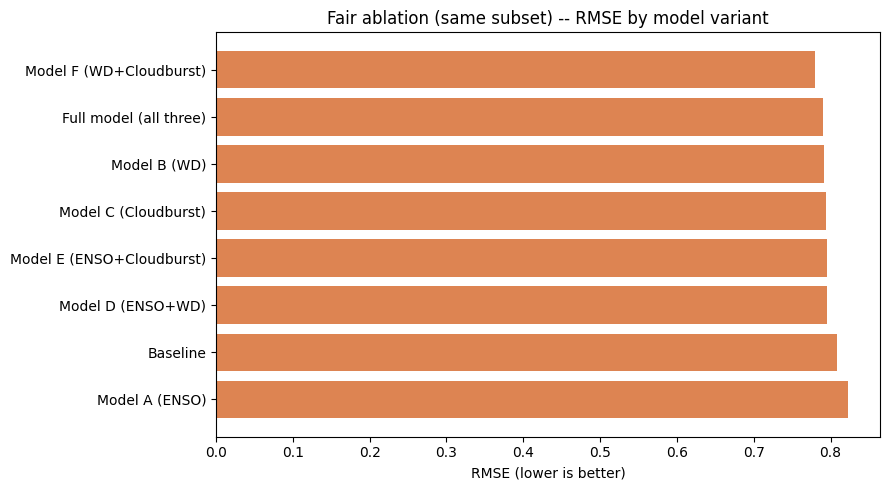

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fair_results_df["Model"], fair_results_df["RMSE"], color="#DD8452")
ax.set_xlabel("RMSE (lower is better)")
ax.set_title("Fair ablation (same subset) -- RMSE by model variant")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Next steps

1. Extend the Cloudburst vertical beyond its current 5 districts to match the full
   ICRISAT district list, so Cloudburst-involving variants stop losing sample size.
2. If district-level WD data becomes available (vs. India-wide), re-aggregate at
   district x year instead of year-only for a stronger signal.
3. Double check the ICRISAT `Year` = crop-year assumption against ICRISAT's data
   documentation if exact seasonal alignment matters for the final report.
4. Consider adding more crops beyond Wheat/Rice if the report needs broader coverage.